# Carousel Lens — HST Data Setup

Downloads and prepares HST imaging for gigalens modeling.

**System:** DESJ0603-3558 (Carousel Lens / ACT-CL J0603.9-3557)  
**HST Program:** GO-16773  
**Datasets:** IENHC7010 (WFC3/IR F140W), IENHC7020 (WFC3/UVIS F200LP)  
**Coordinates:** RA=90.98536, Dec=-35.97054 (J2000)  
**Reference:** Urcelay et al. 2026 (arXiv:2602.16077)

Run cells in order. Outputs saved to `data/`.

In [1]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import simple_norm
from astropy.nddata import Cutout2D
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 150

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# Carousel Lens center
CAROUSEL_RA  = 90.98536495366
CAROUSEL_DEC = -35.970539557157
lens_coord = SkyCoord(ra=CAROUSEL_RA*u.deg, dec=CAROUSEL_DEC*u.deg)

print('Setup complete')

Setup complete


## 1. Download HST Data from MAST

Requires `astroquery`. Install with:
```
pip install astroquery
```

Downloads the drizzled science images for program GO-16773.

In [2]:
!pip install astroquery

In [3]:
from astroquery.mast import Observations

# Query all observations for program 16773 at the carousel lens target
obs_table = Observations.query_criteria(
    proposal_id='16773',
    target_name='DESJ0603-3558'
)
print(f'Found {len(obs_table)} observations')
print(obs_table['obs_id', 'instrument_name', 'filters', 't_exptime', 'target_name'])

Found 6 observations
               obs_id                instrument_name ...  target_name 
------------------------------------ --------------- ... -------------
                           ienhc7020       WFC3/UVIS ... DESJ0603-3558
                           ienhc7010         WFC3/IR ... DESJ0603-3558
   hst_16773_c7_wfc3_ir_f140w_ienhc7         WFC3/IR ... DESJ0603-3558
hst_16773_c7_wfc3_uvis_f200lp_ienhc7       WFC3/UVIS ... DESJ0603-3558
   hst_16773_c7_wfc3_ir_total_ienhc7         WFC3/IR ... DESJ0603-3558
 hst_16773_c7_wfc3_uvis_total_ienhc7       WFC3/UVIS ... DESJ0603-3558


In [4]:
# Get list of available data products
products = Observations.get_product_list(obs_table)

# Filter to drizzled science images only
drz_products = Observations.filter_products(
    products,
    productSubGroupDescription='DRZ',
    extension='fits',
)
print(f'Drizzled products to download:')
print(drz_products['obsID', 'productFilename', 'size', 'description'])

Drizzled products to download:
 obsID   ...                          description                         
-------- ... -------------------------------------------------------------
87528659 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528659 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528659 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528661 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528661 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528661 ... DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS
87528663 ...                                        HAP fits science image
87528663 ...                                        HAP fits science image
87528663 ...                                        HAP fits science image
87528664 ...                                        HAP fits science image
     ... ...                                                         

In [5]:
# Download — files go into DATA_DIR
manifest = Observations.download_products(drz_products, download_dir=DATA_DIR)
print('Downloaded:')
for row in manifest:
    print(' ', row['Local Path'])

INFO: 18 of 31 products were duplicates. Only returning 13 unique product(s). [astroquery.mast.utils]
INFO: Found cached file ./data/mastDownload/HST/ienhc7020/ienhc7020_drz.fits with expected size 217313280. [astroquery.query]
INFO: Found cached file ./data/mastDownload/HST/ienhc7010/ienhc7010_drz.fits with expected size 14034240. [astroquery.query]
INFO: Found cached file ./data/mastDownload/HST/hst_16773_c7_wfc3_ir_f140w_ienhc7u2/hst_16773_c7_wfc3_ir_f140w_ienhc7u2_drz.fits with expected size 27313920. [astroquery.query]
INFO: Found cached file ./data/mastDownload/HST/hst_16773_c7_wfc3_ir_f140w_ienhc7u6/hst_16773_c7_wfc3_ir_f140w_ienhc7u6_drz.fits with expected size 27313920. [astroquery.query]
INFO: Found cached file ./data/mastDownload/HST/hst_16773_c7_wfc3_ir_f140w_ienhc7u4/hst_16773_c7_wfc3_ir_f140w_ienhc7u4_drz.fits with expected size 27313920. [astroquery.query]
INFO: Found cached file ./data/mastDownload/HST/hst_16773_c7_wfc3_ir_f140w_ienhc7/hst_16773_c7_wfc3_ir_f140w_ienhc7_

## 2. Locate Downloaded Files

MAST places files under `data/mastDownload/HST/<obs_id>/`. Adjust paths below if needed.

**Alternatively**, if you already have the processed images from `sean-carousel/`, point directly to those.

In [6]:
import glob

# Auto-locate drizzled F140W file
f140w_candidates = glob.glob(f'{DATA_DIR}/**/*f140w*drz_sci*', recursive=True) + \
                   glob.glob(f'{DATA_DIR}/**/*drz_sci*', recursive=True)

# Fallback to sean-carousel processed data
SEAN_DATA = '../sean-carousel/model_data'
if not f140w_candidates and os.path.exists(f'{SEAN_DATA}/f140w_img_large.fits'):
    print('Using existing processed image from sean-carousel')
    F140W_PATH = f'{SEAN_DATA}/f140w_img_large.fits'
else:
    # Pick the first F140W drizzled file
    f140w_files = [p for p in f140w_candidates if 'ienhc7010' in p.lower() or 'f140w' in p.lower()]
    F140W_PATH = f140w_files[0] if f140w_files else f140w_candidates[0]

print(f'F140W image: {F140W_PATH}')

Using existing processed image from sean-carousel
F140W image: ../sean-carousel/model_data/f140w_img_large.fits


## 3. Inspect the Image

Filename: ../sean-carousel/model_data/f140w_img_large.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   (1500, 1500)   float64   
Shape : (1500, 1500)
EXPTIME: 597.694383 s
BKGRMS : 0.006958211939640636
Pixel scale: 0.0698 arcsec/pixel


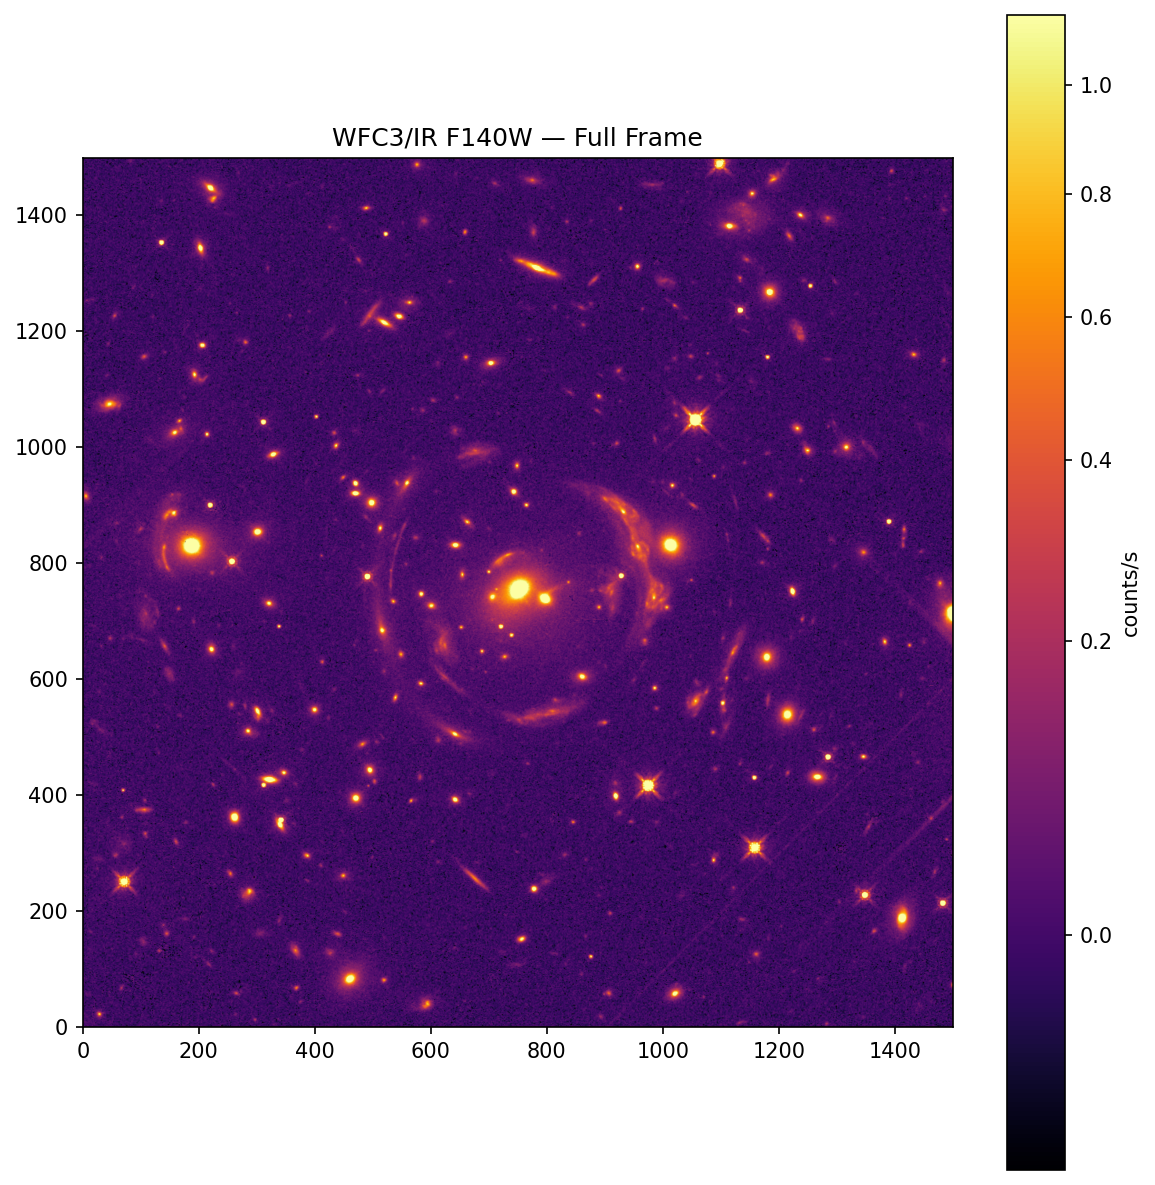

In [7]:
with fits.open(F140W_PATH) as hdul:
    hdul.info()
    hdr = hdul[0].header
    img_full = hdul[0].data.astype(np.float64)
    wcs = WCS(hdr)

print(f'Shape : {img_full.shape}')
print(f'EXPTIME: {hdr.get("EXPTIME", "?")} s')
print(f'BKGRMS : {hdr.get("BKGRMS", "?")}')

# Pixel scale from WCS
pc = np.array([[hdr.get('PC1_1', 0), hdr.get('PC1_2', 0)],
               [hdr.get('PC2_1', 0), hdr.get('PC2_2', 0)]])
delta_pix_deg = np.sqrt(np.sum(pc[0]**2))  # degrees/pixel
delta_pix_arcsec = delta_pix_deg * 3600
print(f'Pixel scale: {delta_pix_arcsec:.4f} arcsec/pixel')

norm = simple_norm(img_full, 'sqrt', percent=99.5)
plt.figure(figsize=(8,8))
plt.imshow(img_full, norm=norm, origin='lower', cmap='inferno')
plt.title('WFC3/IR F140W — Full Frame')
plt.colorbar(label='counts/s')
plt.tight_layout()
plt.show()

## 4. Create Cutout at Carousel Lens Center

Following Felipe's paper: the modeling region covers the cluster core.
We cut a square centered on the BCG/lens center.

Lens center in full image: pixel (656.7, 680.5)
Cutout shape: (500, 500)
Pixel scale: 0.06983 arcsec/pix
Field of view: 34.9"


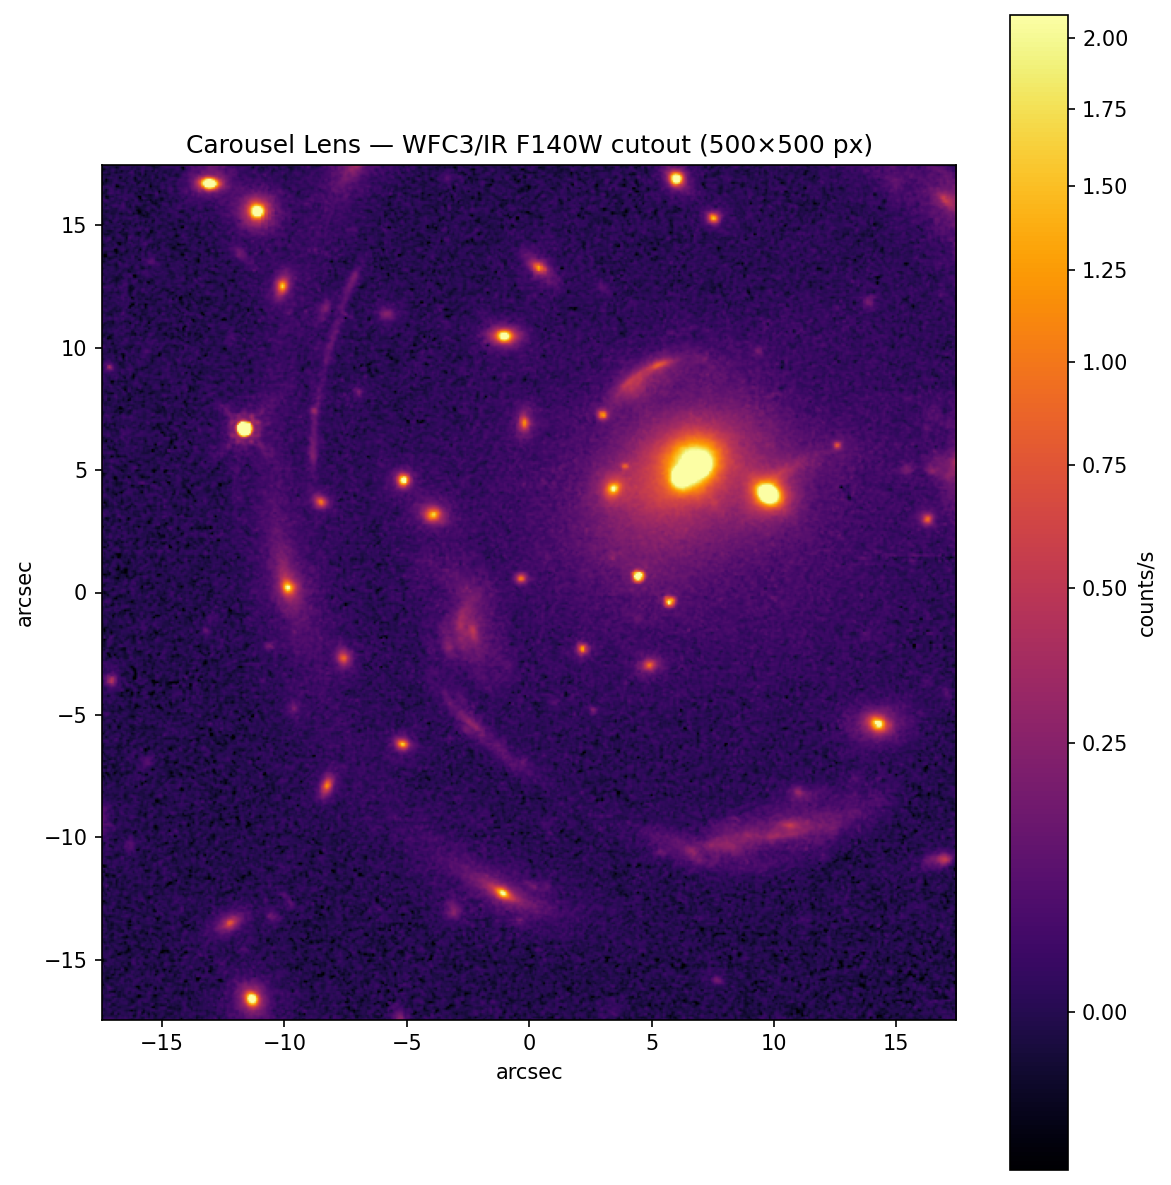

In [8]:
# Cutout size — adjust to match Felipe's setup
# At 0.065"/px: 308 px ≈ 20", 500 px ≈ 32.5", 800 px ≈ 52"
CUTOUT_PIX = 500  # pixels — tweak based on paper

with fits.open(F140W_PATH) as hdul:
    hdr = hdul[0].header
    img_full = hdul[0].data.astype(np.float64)
    wcs_full = WCS(hdr)
    exp_time = float(hdr.get('EXPTIME', 597.694383))
    bkg_rms  = float(hdr.get('BKGRMS', 0.0))

# Project lens center to pixel
xc, yc = wcs_full.all_world2pix(CAROUSEL_RA, CAROUSEL_DEC, 0)
print(f'Lens center in full image: pixel ({xc:.1f}, {yc:.1f})')

# Make cutout
from astropy.nddata import Cutout2D
cutout = Cutout2D(img_full, position=(xc, yc), size=CUTOUT_PIX, wcs=wcs_full, mode='partial', fill_value=0.0)
img_cut = cutout.data
wcs_cut = cutout.wcs

print(f'Cutout shape: {img_cut.shape}')

# Pixel scale
pc = np.array([[hdr.get('PC1_1', 0), hdr.get('PC1_2', 0)],
               [hdr.get('PC2_1', 0), hdr.get('PC2_2', 0)]])
delta_pix_arcsec = np.sqrt(np.sum(pc[0]**2)) * 3600
print(f'Pixel scale: {delta_pix_arcsec:.5f} arcsec/pix')
print(f'Field of view: {CUTOUT_PIX * delta_pix_arcsec:.1f}"')

norm_cut = simple_norm(img_cut, 'sqrt', percent=99.5)
extent = (-CUTOUT_PIX/2*delta_pix_arcsec, CUTOUT_PIX/2*delta_pix_arcsec,
          -CUTOUT_PIX/2*delta_pix_arcsec, CUTOUT_PIX/2*delta_pix_arcsec)

plt.figure(figsize=(8,8))
plt.imshow(img_cut, norm=norm_cut, origin='lower', cmap='inferno', extent=extent)
plt.xlabel('arcsec')
plt.ylabel('arcsec')
plt.title(f'Carousel Lens — WFC3/IR F140W cutout ({CUTOUT_PIX}×{CUTOUT_PIX} px)')
plt.colorbar(label='counts/s')
plt.tight_layout()
plt.show()

## 5. Background Estimation

In [9]:
from astropy.stats import sigma_clipped_stats
from photutils.background import Background2D, MedianBackground

# Sigma-clipped stats on the cutout (quick global estimate)
mean, median, std = sigma_clipped_stats(img_cut, sigma=3.0, maxiters=10)
print(f'Sigma-clipped stats:')
print(f'  mean  = {mean:.6f}')
print(f'  median= {median:.6f}')
print(f'  std   = {std:.6f}  ← use as background_rms')

# 2D background map (more accurate)
bkg = Background2D(img_cut, box_size=50, filter_size=3, bkg_estimator=MedianBackground())
bkg_level = bkg.background_median
bkg_rms_2d = bkg.background_rms_median
print(f'\n2D background map:')
print(f'  median level = {bkg_level:.6f}')
print(f'  median RMS   = {bkg_rms_2d:.6f}')

# Subtract background
img_bkgsub = img_cut - bkg.background

BACKGROUND_RMS = float(std)  # use this in gigalens
print(f'\nUsing background_rms = {BACKGROUND_RMS:.6f}')

Sigma-clipped stats:
  mean  = 0.015582
  median= 0.012367
  std   = 0.024747  ← use as background_rms

2D background map:
  median level = 0.012126
  median RMS   = 0.018277

Using background_rms = 0.024747


## 6. PSF

Two options:
- **Empirical**: extract from stars in the field (preferred)
- **Gaussian**: analytical approximation (quick)

WFC3/IR F140W native FWHM ≈ 0.19" (PSF-model from STScI/TinyTim).  
After drizzle to ~0.065"/px this is ~2.9 pixels FWHM.

PSF FWHM: 0.19" = 2.72 px
PSF kernel shape: (31, 31)


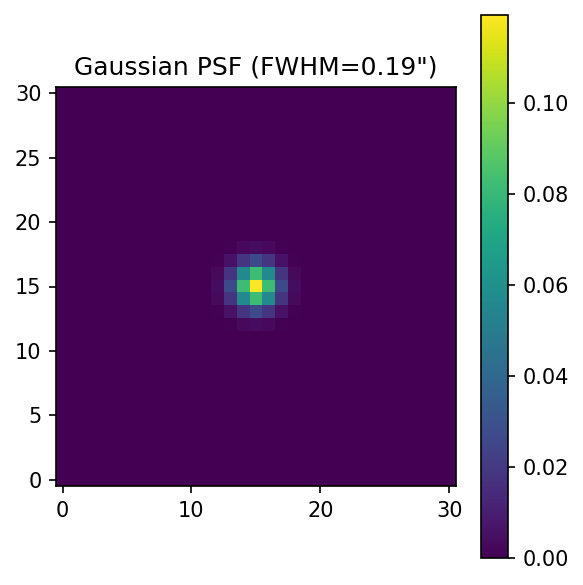

In [10]:
from photutils.psf import GaussianPSF

# Gaussian PSF approximation — matches sean-carousel setup
# Sean uses FWHM = 0.717821594376891 arcsec (this seems large, likely for MUSE data)
# For HST WFC3/IR F140W drizzled to 0.065"/px: FWHM ~ 0.19" ≈ 2.92 px

# Try to measure from a star in the field first:
PSF_FWHM_ARCSEC = 0.19  # WFC3/IR F140W approximate
PSF_FWHM_PIX = PSF_FWHM_ARCSEC / delta_pix_arcsec
print(f'PSF FWHM: {PSF_FWHM_ARCSEC}" = {PSF_FWHM_PIX:.2f} px')

psf_size = 15  # kernel half-size in pixels
psf_model = GaussianPSF(x_fwhm=PSF_FWHM_PIX, y_fwhm=PSF_FWHM_PIX)
yy, xx = np.mgrid[-psf_size:psf_size+1, -psf_size:psf_size+1]
kernel = psf_model(xx, yy)
kernel /= kernel.sum()

print(f'PSF kernel shape: {kernel.shape}')

plt.figure(figsize=(4,4))
plt.imshow(kernel, origin='lower', cmap='viridis')
plt.colorbar()
plt.title(f'Gaussian PSF (FWHM={PSF_FWHM_ARCSEC}")')
plt.tight_layout()
plt.show()

In [11]:
# Optional: empirical PSF from stars
# Use photutils.psf.EPSFBuilder on isolated stars in the field
# Uncomment and adapt if stars are available

# from photutils.detection import DAOStarFinder
# from photutils.psf import EPSFBuilder, extract_stars
# from astropy.table import Table
#
# daofind = DAOStarFinder(fwhm=PSF_FWHM_PIX, threshold=50*BACKGROUND_RMS)
# sources = daofind(img_bkgsub)
# print(f'Found {len(sources)} sources')
#
# stars_tbl = Table()
# stars_tbl['x'] = sources['xcentroid']
# stars_tbl['y'] = sources['ycentroid']
# stars = extract_stars(NDData(data=img_bkgsub), stars_tbl, size=25)
# epsf_builder = EPSFBuilder(oversampling=2, maxiters=10, progress_bar=True)
# epsf, fitted_stars = epsf_builder(stars)
# kernel = epsf.data / epsf.data.sum()

print('Using Gaussian PSF (empirical ePSF commented out above)')

Using Gaussian PSF (empirical ePSF commented out above)


## 7. Save Prepared Data

In [12]:
# Save cutout image as FITS (preserves WCS)
cutout_hdr = wcs_cut.to_header()
cutout_hdr['EXPTIME'] = exp_time
cutout_hdr['BKGRMS']  = BACKGROUND_RMS
cutout_hdr['FILTER']  = 'F140W'
cutout_hdr['INSTRUME'] = 'WFC3/IR'
cutout_hdr['PROPOSID'] = 16773
cutout_hdr['TARGNAME'] = 'DESJ0603-3558'

fits.writeto(f'{DATA_DIR}/f140w_img.fits', img_bkgsub.astype(np.float32),
             header=cutout_hdr, overwrite=True)

# Save PSF
np.save(f'{DATA_DIR}/psf.npy', kernel.astype(np.float32))

# Save imaging parameters for boiler.py
import json
params = dict(
    numPix      = int(CUTOUT_PIX),
    deltaPix    = float(delta_pix_arcsec),
    exp_time    = float(exp_time),
    background_rms = float(BACKGROUND_RMS),
    psf_fwhm_arcsec = float(PSF_FWHM_ARCSEC),
    ra          = CAROUSEL_RA,
    dec         = CAROUSEL_DEC,
    hst_program = 16773,
    filter      = 'F140W',
)
with open(f'{DATA_DIR}/imaging_params.json', 'w') as f:
    json.dump(params, f, indent=2)

print('Saved:')
print(f'  {DATA_DIR}/f140w_img.fits     — background-subtracted cutout')
print(f'  {DATA_DIR}/psf.npy            — PSF kernel (normalized)')
print(f'  {DATA_DIR}/imaging_params.json — pixel scale, exptime, noise')
print()
print('Summary:')
print(f'  numPix      = {CUTOUT_PIX}')
print(f'  deltaPix    = {delta_pix_arcsec:.5f} arcsec/pix')
print(f'  exp_time    = {exp_time} s')
print(f'  bkg_rms     = {BACKGROUND_RMS:.6f} counts/s')

Saved:
  ./data/f140w_img.fits     — background-subtracted cutout
  ./data/psf.npy            — PSF kernel (normalized)
  ./data/imaging_params.json — pixel scale, exptime, noise

Summary:
  numPix      = 500
  deltaPix    = 0.06983 arcsec/pix
  exp_time    = 597.694383 s
  bkg_rms     = 0.024747 counts/s


## 8. Final Sanity Check

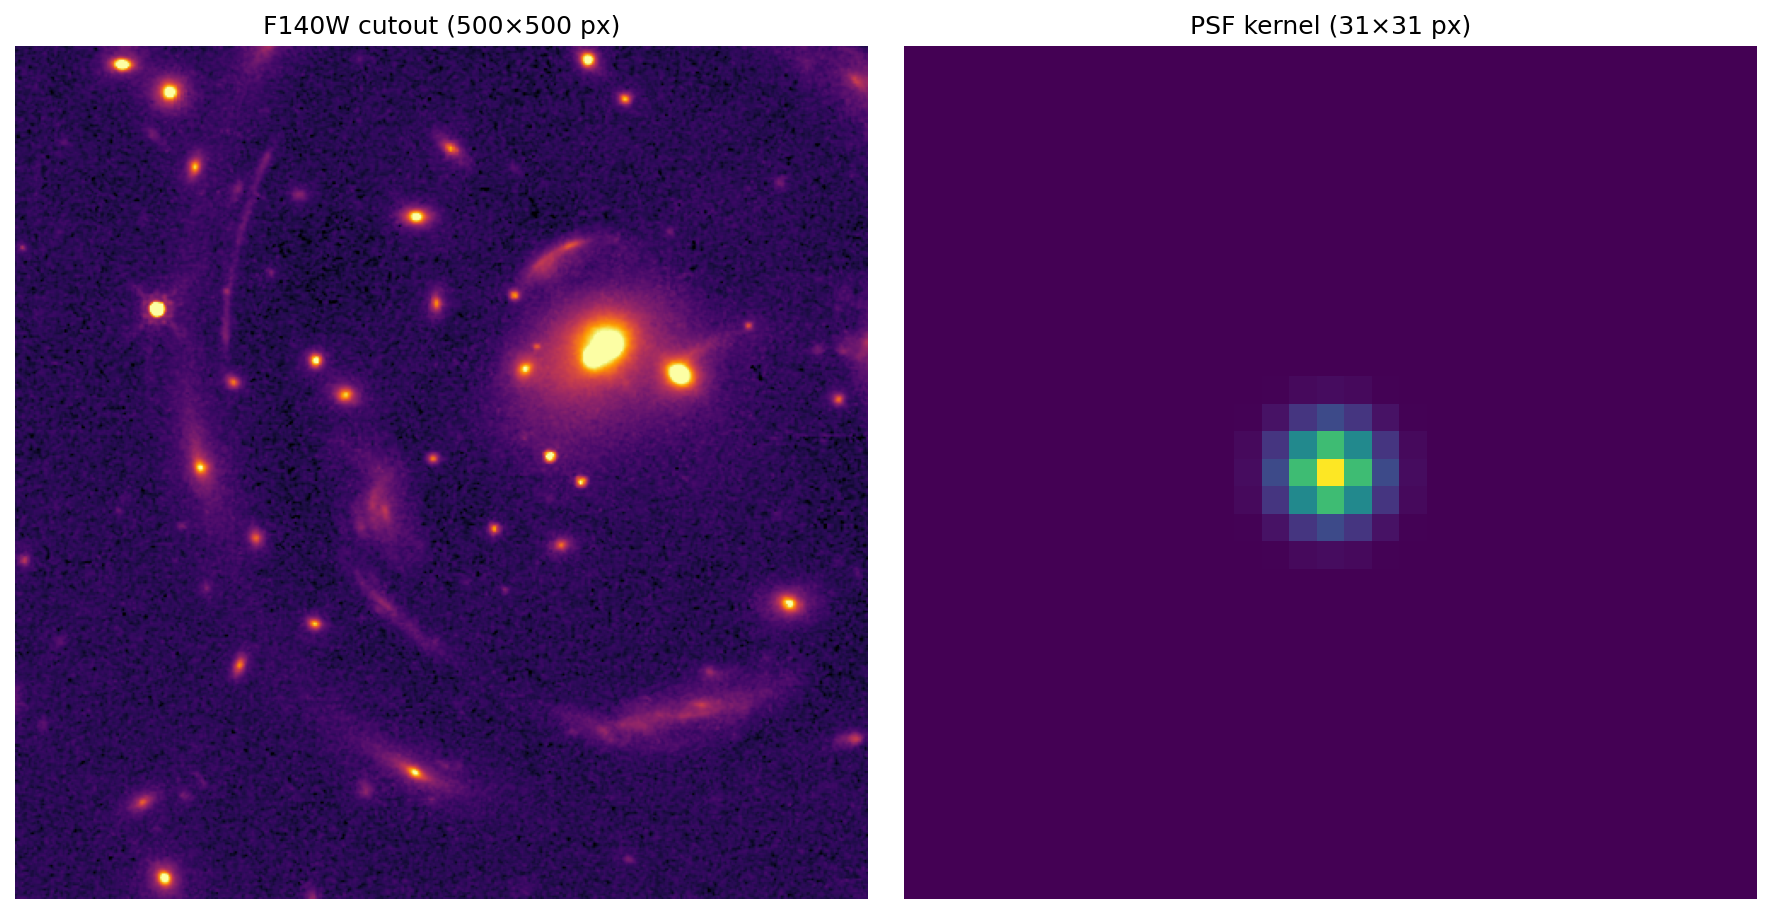

Data ready for gigalens modeling.


In [16]:
# Reload and display the saved image
with fits.open(f'{DATA_DIR}/f140w_img.fits') as hdul:
    img_check = hdul[0].data
    hdr_check = hdul[0].header

psf_check = np.load(f'{DATA_DIR}/psf.npy')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

norm_c = simple_norm(img_check, 'sqrt', percent=99.5)
axes[0].imshow(img_check, norm=norm_c, origin='lower', cmap='inferno')
axes[0].set_title(f'F140W cutout ({img_check.shape[0]}×{img_check.shape[1]} px)')
axes[0].axis('off')

axes[1].imshow(psf_check, origin='lower', cmap='viridis')
axes[1].set_title(f'PSF kernel ({psf_check.shape[0]}×{psf_check.shape[1]} px)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/data_check.png', dpi=150)
plt.show()

print('Data ready for gigalens modeling.')

In [17]:
"""
North-up rotation + RGB composite.

The raw F140W image has HST roll angle ~55° from North-up.
We rotate both F140W and F200LP to North-up and save as the CANONICAL data arrays.
All downstream priors and positions are transformed to this coordinate system.
"""
from scipy.ndimage import zoom as nd_zoom, rotate as nd_rotate
import json

F140W_RAW  = '../sean-carousel/model_data/f140w_img.fits'
F200LP_RAW = '../sean-carousel/model_data/f200lp_img_large.fits'
PSF_RAW    = '../carousel-lens/psf.npy'

BIN = 2   # 2×2 spatial binning to reduce memory

# ── Load F140W ────────────────────────────────────────────────────────────────
with fits.open(F140W_RAW) as h:
    obs_native = h[0].data.astype(np.float32)
    hdr        = h[0].header
    exp_time   = float(hdr['EXPTIME'])
    bkg_rms    = float(hdr['BKGRMS'])
    pc = np.array([[hdr['PC1_1'], hdr['PC1_2']], [hdr['PC2_1'], hdr['PC2_2']]])

hh, ww = obs_native.shape
obs_bin = obs_native[:hh//BIN*BIN, :ww//BIN*BIN].reshape(hh//BIN, BIN, ww//BIN, BIN).mean(axis=(1,3))
delta_pix = np.sqrt(np.sum(pc[0]**2)) * 3600 * BIN   # arcsec/px after binning
num_pix   = obs_bin.shape[0]
bkg_rms  /= BIN

# ── Load F200LP ───────────────────────────────────────────────────────────────
with fits.open(F200LP_RAW) as h:
    f200_raw = h[0].data.astype(np.float32)
    pc200    = np.array([[h[0].header['PC1_1'], h[0].header['PC1_2']],
                         [h[0].header['PC2_1'], h[0].header['PC2_2']]])
    dp200    = np.sqrt(np.sum(pc200[0]**2)) * 3600   # native arcsec/px

zoom_factor  = dp200 / (delta_pix / BIN)
f200_remap   = nd_zoom(f200_raw, zoom_factor, order=3)
hr, wr       = f200_remap.shape
f200_bin     = f200_remap[:hr//BIN*BIN, :wr//BIN*BIN].reshape(hr//BIN, BIN, wr//BIN, BIN).mean(axis=(1,3))
def match_shape(arr, t):
    th, tw = t; h, w = arr.shape
    r0 = max(0,(h-th)//2); c0 = max(0,(w-tw)//2)
    arr = arr[r0:r0+th, c0:c0+tw]
    ph = max(0, th-arr.shape[0]); pw = max(0, tw-arr.shape[1])
    return np.pad(arr, ((ph//2,ph-ph//2),(pw//2,pw-pw//2)))
f200_bin = match_shape(f200_bin, obs_bin.shape)

# ── North-up rotation ─────────────────────────────────────────────────────────
north_angle = np.degrees(np.arctan2(pc[1,0], pc[1,1]))   # ≈ 55.4°
CROP_PX     = 400   # px; covers ±28" — includes Ld at ~26"

def to_north(arr, cval=0., order=3):
    r = nd_rotate(arr, -north_angle, reshape=True, order=order, cval=cval)
    rh, rw = r.shape
    r0 = (rh-CROP_PX)//2; c0 = (rw-CROP_PX)//2
    return r[r0:r0+CROP_PX, c0:c0+CROP_PX]

obs  = to_north(obs_bin)
f200 = to_north(f200_bin)
print(f'Rotated to North-up: {north_angle:.2f}°  →  obs shape: {obs.shape}  ({CROP_PX*delta_pix:.1f}" FoV)')

# ── RGB composite ─────────────────────────────────────────────────────────────
def norm_ch(d, lo=0.5, hi=99.9):
    pos = d[d > 0]; vlo, vhi = np.nanpercentile(pos, [lo, hi])
    return np.sqrt(np.clip((d-vlo)/(vhi-vlo), 0, 1))

rgb = np.clip(np.stack([norm_ch(obs), norm_ch((obs+f200)/2), norm_ch(f200)], axis=-1), 0, 1)

Rotated to North-up: 54.24°  →  obs shape: (400, 400)  (55.9" FoV)


In [ ]:
"""
Transform all published Sheu+2024 Table 2 lens parameters from native pixel
coordinates to the North-up coordinate system.

Note: Sheu+2024 does NOT tabulate source positions — only lens mass parameters.
Source positions must be found interactively via the forward-model mask tuner
in source4.ipynb (start from La's centre and tune until 4 blobs appear).

Rotation by θ = north_angle clockwise → coordinate frame rotates CCW by θ.
Positions  (spin-1): x' =  x·cos θ + y·sin θ
                     y' = -x·sin θ + y·cos θ
Spin-2     (e,γ):   c1' = c1·cos 2θ + c2·sin 2θ
                    c2' = -c1·sin 2θ + c2·cos 2θ
"""
θ  = np.radians(north_angle)
c1, s1 = np.cos(θ), np.sin(θ)
c2, s2 = np.cos(2*θ), np.sin(2*θ)

def rot_pos(x, y): return x*c1 + y*s1,  -x*s1 + y*c1
def rot_s2(a, b):  return a*c2 + b*s2,  -a*s2 + b*c2

# Native Sheu+2024 Table 2 values
_la_cx, _la_cy = 6.70,  4.80
_ld_cx, _ld_cy = 11.81, 23.03   # Sean's MUSE MAP — not in paper

la_cx, la_cy = rot_pos(_la_cx, _la_cy)
ld_cx, ld_cy = rot_pos(_ld_cx, _ld_cy)

la_e1, la_e2 = rot_s2( 0.000, -0.069)
ld_e1, ld_e2 = rot_s2( 0.044, -0.178)
sh_g1, sh_g2 = rot_s2( 0.105,  0.034)

meta = dict(
    delta_pix   = float(delta_pix),
    num_pix     = int(CROP_PX),
    exp_time    = float(exp_time),
    bkg_rms     = float(bkg_rms),
    north_angle = float(north_angle),
    # La (EPL) — Sheu+2024 Table 2, transformed to North-up
    la_cx=la_cx, la_cy=la_cy, la_e1=la_e1, la_e2=la_e2,
    la_thetaE=13.03, la_gamma=1.67,
    # Ld (EPL) — Sheu+2024 Table 2, position from Sean's MUSE MAP
    ld_cx=ld_cx, ld_cy=ld_cy, ld_e1=ld_e1, ld_e2=ld_e2,
    ld_thetaE=0.99, ld_gamma=2.12,
    # Shear — Sheu+2024 Table 2
    sh_g1=sh_g1, sh_g2=sh_g2,
    # deflection ratio for S4 (z_s=1.432, FlatLCDM H0=70 Om0=0.3 z_l=0.49)
    dr_s4=0.5619,
)

for k, v in meta.items():
    if isinstance(v, float): print(f'  {k:15s} = {v:+.4f}')
    else:                     print(f'  {k:15s} = {v}')

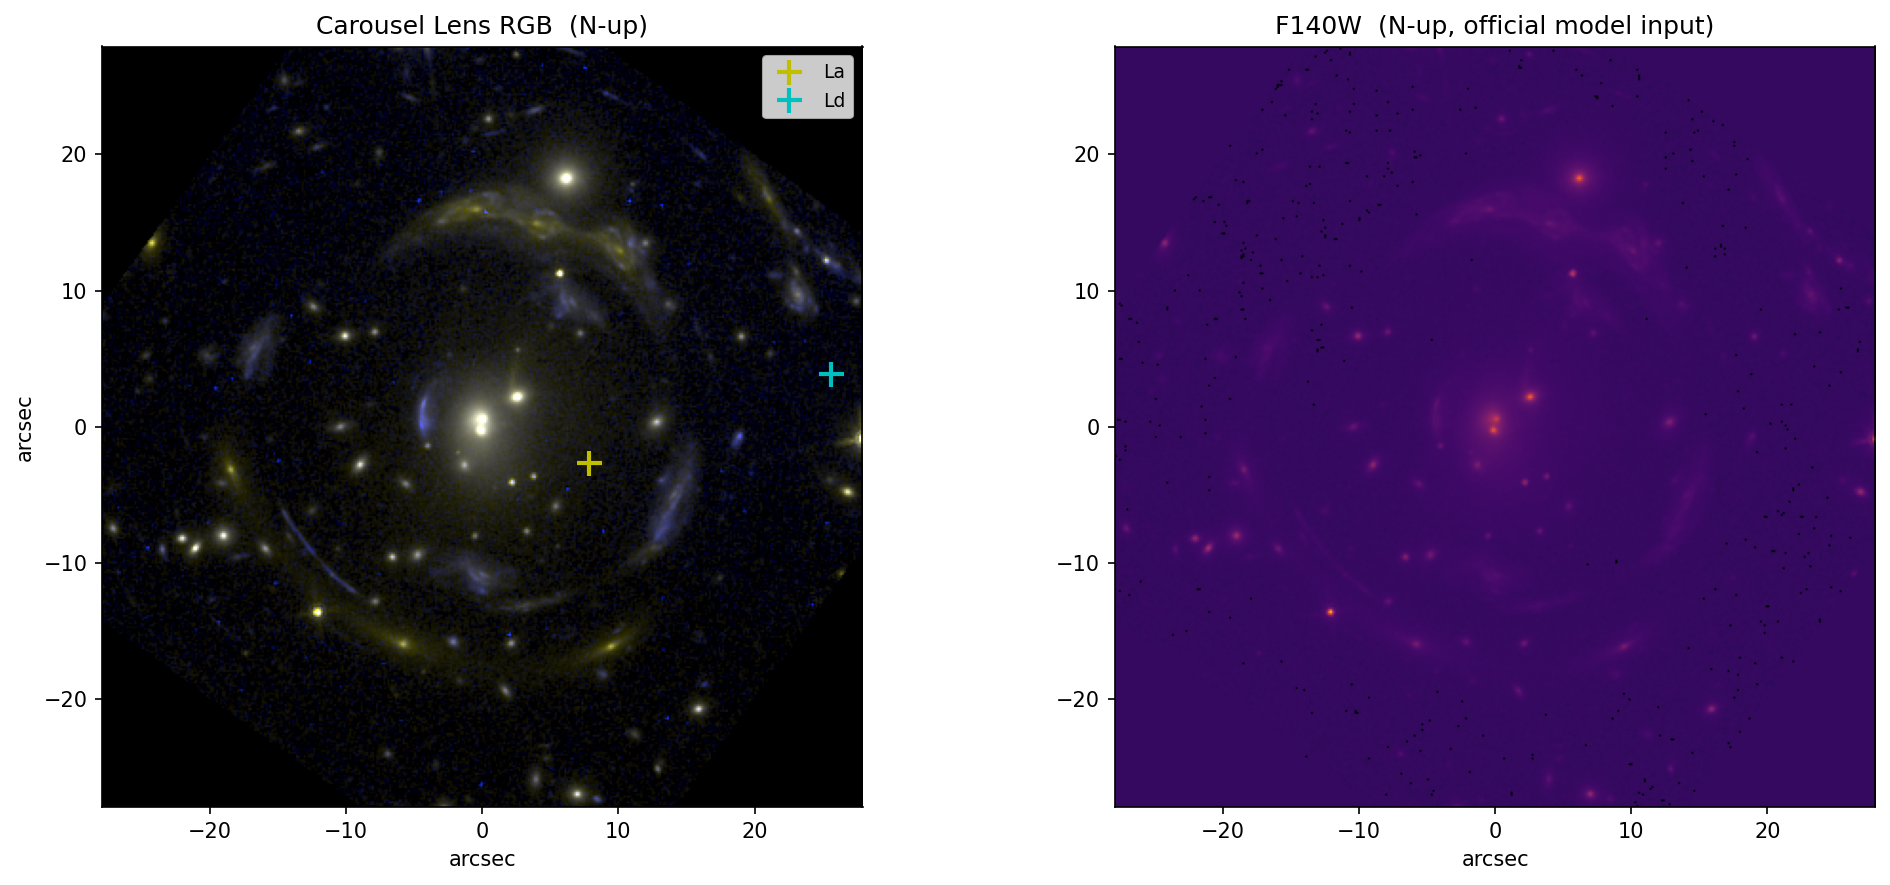

Saved to data/:
  obs.npy               625 kB
  f200.npy              625 kB
  rgb.npy               1875 kB
  kernel.npy            6 kB
  meta.json             1 kB


In [19]:
import os
os.makedirs('data', exist_ok=True)

kernel = np.load(PSF_RAW).astype(np.float64)
kernel /= kernel.sum()

np.save('data/obs.npy',  obs.astype(np.float32))
np.save('data/f200.npy', f200.astype(np.float32))
np.save('data/rgb.npy',  rgb.astype(np.float32))
np.save('data/kernel.npy', kernel)

with open('data/meta.json', 'w') as f:
    json.dump({k: (float(v) if isinstance(v, (np.floating, float)) else v)
               for k, v in meta.items()}, f, indent=2)

ext = (-CROP_PX/2*delta_pix, CROP_PX/2*delta_pix,
       -CROP_PX/2*delta_pix, CROP_PX/2*delta_pix)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(rgb, origin='lower', extent=ext)
axes[0].plot(meta['la_cx'], meta['la_cy'], 'y+', ms=12, mew=2, label='La')
axes[0].plot(meta['ld_cx'], meta['ld_cy'], 'c+', ms=12, mew=2, label='Ld')
axes[0].legend(fontsize=9)
axes[0].set(title='Carousel Lens RGB  (N-up)', xlabel='arcsec', ylabel='arcsec')

axes[1].imshow(simple_norm(obs, 'sqrt', percent=99.5)(obs), origin='lower',
               cmap='inferno', extent=ext)
axes[1].set(title='F140W  (N-up, official model input)', xlabel='arcsec')

plt.tight_layout()
plt.savefig('data/rgb_check.png', dpi=150)
plt.show()

print('Saved to data/:')
for f in ['obs.npy','f200.npy','rgb.npy','kernel.npy','meta.json']:
    size = os.path.getsize(f'data/{f}') / 1024
    print(f'  {f:20s}  {size:.0f} kB')